In [1]:
# capstone project -- function 5 (4D), week N

import numpy as np
import warnings
import matplotlib.pyplot as plt

from itertools import product
from scipy.spatial import Delaunay, ConvexHull  # convex-hull check on the proposal
from scipy.stats import spearmanr, pearsonr     # model-free cross-check on the ARD verdict

from bayes_tools import (
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 5

4D, 20 initial points plus 1 collected. **Using UCB with `kappa=1.0`, restricted to x2** -- the axis the current model says dominates. Reasoning below.

Proposal this week: **`[0.256210, 0.903056, 1.365584, 1.065351]`** (GP mean +7344, std 1856; predicted to beat the current best of 6146.8 by ~1197).

Built on `function4.ipynb`'s structure, but almost every *decision* differs -- function 5 is close to function 4's mirror image. There is no project-wide best approach; each function is decided from its own evidence.

## The one collected point is the new best, by 5.65x

`y = 6146.78` against a previous best of `1088.86`. Two features matter:

- It came from **extrapolating outside the observed data**. Three of its four coordinates are beyond anything previously sampled (x1=0.903 vs max 0.863; x2=1.106 vs 0.880; x3=1.065 vs 0.958). Pushing outward paid off enormously.
- The GP **under-predicted it by 17 sigma**: fitted on the initial 20 points, it expected `1685.8 +/- 263.1` and got `6146.8`. That is a severe calibration failure, and it is directional -- the true surface climbs far faster than the model believed in the direction we moved.

Unlike function 4's recorded point, this one has no provenance problem: the old sweep proposed exactly these coordinates, all positive, and none sits on a bound. `validate_bounds_consistency` passes without adjustment.

## Consequence: do NOT constrain the search to the data here

This is the sharpest contrast with functions 3 and 4, both of which restrict or check against the observed region because extrapolation there was either arbitrary or catastrophic (function 4's outlying evaluation returned -215).

On function 5 the opposite holds, and it is easy to demonstrate: the GP mean along x2 is **still climbing at the edge of the observed data**. Optimising UCB along x2 while clamped to the observed range just returns the incumbent's own x2 (1.1059) at every `kappa` -- i.e. clamping would spend the week re-evaluating a point we already have. The proposal below is deliberately outside the convex hull. The hull check is still run, but here it is reported for information rather than used as a veto.

## Which axes to search: x2 dominates the model, but x3 is contested

The GP fits length-scales of **[10.0, 10.0, 0.263, 9.07]** -- x0 and x1 pinned at the ceiling, x3 nearly so, x2 short. Because a long length-scale means "smooth, nearly linear" rather than strictly "no effect", that was checked directly by sweeping each axis with the others held at the incumbent:

| axis | mean varies by, across full bounds | length-scale now | length-scale before the new point | spearman(y) | pearson(log y) |
|---|---|---|---|---|---|
| x0 | 271 | 10.0 (pinned) | 10.0 | -0.199 | -0.185 |
| x1 | 282 | 10.0 (pinned) | 6.18 | +0.269 | +0.150 |
| x2 | **7691** | 0.263 | 0.50 | +0.370 | +0.481 |
| x3 | 245 | 9.07 | **0.25 (most informative)** | **+0.635** | **+0.656** |

By the GP sweep, x2 moves the response roughly **28x more** than any other axis. But the model-free columns disagree: **x3 has the strongest monotone association with `y` of any axis**, and before the new observation arrived the GP itself rated x3 the most informative dimension. Only the post-outlier fit calls it irrelevant, and that flip came from adding a single point. Two of three lines of evidence say x3 matters.

x3 is nonetheless **excluded on cost/benefit, not on irrelevance** -- an important distinction, and one the notebook measures rather than asserts. Every search subset containing x3 pushes it to its **upper bound (1.8424) at every `kappa`**, about 73% beyond the furthest x3 ever observed. What that buys falls away as `kappa` rises: about **+5.3%** predicted mean at `kappa=0`, **+1.4%** at the committed `kappa=1`, then *negative* (-9.3%, -21.2%) at `kappa=2` and `kappa=3`. A large extrapolation on a contested axis for a few percent at best, and for near-nothing at the operating point.

So the proposal holds x0/x1/x3 at the incumbent and searches x2 only. Same construction as `function3.ipynb`, reached independently and with the opposite conclusion about extrapolation. Tightening `pad_fraction` does not help: at 0.15, 0.25 and 0.5 *all four* coordinates end up on bounds, because the acquisition still wants the edge and the edge is simply closer. Restricting which axes are searched is the effective handle.

## Why `kappa=1.0` -- length-scale distance, not the mean's peak

Along x2, with the other axes fixed at the incumbent:

| `kappa` | x2 | step | length-scales past last obs. | pred. mean | pred. std |
|---|---|---|---|---|---|
| 0 (= `exploit`) | 1.2745 | +0.169 | 0.38 | +7662 | 1217 |
| **1.0** | **1.3656** | **+0.260** | **0.59** | **+7344** | **1856** |
| 2.0 | 1.4587 | +0.353 | 0.80 | +6569 | 2383 |
| 5.0 | 1.6700 | +0.564 | 1.28 | +4366 | 3083 |

The GP mean does peak near x2=1.2745, but **that peak is a kernel artifact, not a landmark**. It sits only 0.38 of one length-scale past the last observation (0.263 normalised = 0.439 raw), exactly where extrapolated gradient gives way to reversion toward the prior mean of ~437. Model-free there is no turnover at all: `y` is still rising at the largest x2 sampled (0.879 gave 1089, then 1.106 gave 6147). Choosing `kappa` to "step just past the peak" would be calibrating against an artifact.

The criterion actually used is to stay within roughly one length-scale of the data, where the model still carries information. `kappa` 0-2 all land between 0.4 and 0.8 length-scales out; `kappa=1` sits mid-band.

`kappa=5` is rejected structurally rather than by taste: it puts x2 exactly on the upper bound, so `pad_fraction` -- an arbitrary choice -- would be picking the proposal instead of the model. Note the *reverse* of function 4, where `kappa=5` was rejected for jumping to a corner and low `kappa` was safe; here even `kappa=0` is an extrapolation, and that is intentional.

**How thin the evidence is.** Log `y` against x2 gives **r-squared = 0.23**, and the ascent is driven almost entirely by the last two points -- at x2=0.21 `y` is 0.113, while at x2=0.108 it is 233. A log-linear fit extrapolates to ~1585 at the chosen point against the GP's 7344; it under-predicts the incumbent tenfold, so it is not a rival prediction, but it is a reminder that every extrapolation here rests on little.

## What the backtest says -- and why it counts for more here

| config | mean regret | median regret |
|---|---|---|
| `ucb_k5` | 619 | 0 |
| `ucb_k10` | 887 | 0 |
| `max_var` | 953 | 102 |
| `ucb_k2` | 1111 | 0 |
| `ucb_k1` | 1300 | 0 |
| `ei_xi50` | 1301 | 280 |
| `pi_xi50` | 1518 | 351 |
| `exploit` | 1713 | 164 |

This is the **exact inverse of function 4**, where `exploit` won and `max_variance` came last. Ordinarily the backtest deserves little weight because it is structurally biased toward exploitation -- it scores recognition of points whose `y` is already known, which rewards ranking by posterior mean.

That bias is why this particular result is worth more than usual: it favours **exploration** *despite* being rigged against it. The mechanism is visible in the data -- the best point sits far from everything else, so mean-ranking (`exploit`) fails to find it while variance-seeking does. Several UCB configs achieve a median regret of 0, meaning they pick the genuinely best candidate more than half the time.

It does not override the choice of `kappa`, though. Its preference for `kappa=5`/`kappa=10` is really expressing "go far from the data", which in a restricted search just means "hit the box edge" -- the thing ruled out above.

## Why UCB rather than EI or PI

Not a close call on this function. With `xi` sized for raw units, EI and PI both propose `[0.0, 1.687, 1.287, 1.842]` -- three of four coordinates on bounds, the same corner-parking as high-`kappa` UCB but with no dial available to stop it. UCB gives one interpretable knob, and being scale-invariant it needs no y-scaling on a response spanning five orders of magnitude. `exploit` comes last in the backtest, and this is a function where exploration is being rewarded.

## No y-scaling

`y` spans 0.11 to 6146.8, so a default `xi=0.01` is **0.00016%** of the spread -- meaningless. Neither remedy is needed for the chosen acquisition:

- **UCB is scale-invariant** (`mu` and `sigma` are both in `y`-units, so `kappa` is dimensionless). The proposal is unaffected by any rescaling.
- The only scale-sensitive things here are the backtest's PI/EI rows, which use `xi` sized in raw units (50 and 300).
- `fit_y_scale` would give `std(y) = 1299`, dominated by the single largest value and liable to lurch every time a new record arrives.

One tempting idea that is **deliberately not done**: `y` is strictly positive here and spans five orders of magnitude, so a log transform would model it far better -- and note the model-free diagnostics above use `log y` precisely because it behaves better. The project removed its `log1p` transform because `y` can be negative *in general* across these functions, and CLAUDE.md rules out reintroducing anything that assumes `y >= 0`; it would break the moment a negative value arrives. Using `log y` as a read-only diagnostic is fine; putting it in the modelling pipeline is not.

## Standing caution

One observation reshaped the kernel substantially: before it, length-scales were [10, 6.18, 0.5, 0.25] with x2 *and* x3 informative; after, [10, 10, 0.263, 9.07] with x3 effectively irrelevant. A single point flipping x3 from 0.25 to 9.07 is why x3's status is treated as contested rather than settled. Re-run the length-scale, per-axis and subset cells every week; if x3 becomes non-pinned again, revisit the restrict-to-x2 construction -- and give its upper bound explicit thought, because the acquisition will otherwise run straight to it.

## Dimensionality-specific choices

- D=4, so `plot_2d_bo` doesn't apply -- the GP/acquisition view is **`plot_nd_slices`**.
- `plot_bo_diagnostics` and `plot_sample_trajectory` hard-code a 2D scatter panel, so they're **skipped**; the individual trend plots are dimension-agnostic and used instead.
- LOO calibration puts 19/21 points inside their 95% interval, with the new best point the worst-predicted -- which is the 17-sigma miss described above, not a coincidence.

In [2]:
X_initial = np.load("initial_data/function_5/initial_inputs.npy")
y_initial = np.load("initial_data/function_5/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 4, f"Expected a 4D problem, got {D}D input -- check the loaded file."

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week, oldest first -- row order must be true chronological order, or `compute_iteration_diagnostics` at the bottom is meaningless.

One observation is recorded, and it is the new best by a factor of 5.65. Unlike function 4's, this point has clean provenance: the old sweep proposed exactly these coordinates, all positive, none on a bound.

In [3]:
# Append last week's result BEFORE proposing this week's point, e.g.:
#
# new_X, new_y = append_observations(new_X, new_y, x_next, the_result_you_got)

new_X = np.array([
    [0.25621, 0.903056, 1.105882, 1.065351],
])

new_y = np.array([6146.77907747422])

print("observations collected so far:", len(new_y))
print("new y vs previous best: %.3f vs %.3f (%.2fx better)"
      % (new_y[0], y_initial.max(), new_y[0] / y_initial.max()))

observations collected so far: 1
new y vs previous best: 6146.779 vs 1088.860 (5.65x better)


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", np.round(X.min(axis=0), 4))
print("  max:", np.round(X.max(axis=0), 4))
print("y range: %.4f to %.4f (spread %.3f, std %.3f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))

# X is known to never be negative -- lower_limit=0.0 is mandatory.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)
validate_bounds_consistency(X, bounds)
print("\nBounds:\n", np.round(bounds, 4))

# Where does the collected point sit relative to what had been sampled? It is
# an extrapolation on 3 of 4 axes, and it is the best result so far -- the
# reason this notebook does not clamp the search to the observed region.
print("\nthe collected point vs the INITIAL batch's range:")
for d in range(D):
    beyond = new_X[0, d] > X_initial[:, d].max() or new_X[0, d] < X_initial[:, d].min()
    print(f"  x{d}={new_X[0, d]:.4f}  initial range [{X_initial[:, d].min():.4f},"
          f" {X_initial[:, d].max():.4f}]  outside={beyond}")

hull = Delaunay(X)
box = np.column_stack([X.min(axis=0), X.max(axis=0)])
box_volume = float(np.prod(box[:, 1] - box[:, 0]))
try:
    ch = ConvexHull(X)
    print(f"\nobserved bounding box volume: {box_volume:.4g}"
          f" | convex hull volume: {ch.volume:.4g} ({ch.volume / box_volume:.1%} of the box)")
    print(f"{len(ch.vertices)} of {len(X)} observations are convex-hull vertices")
except Exception as exc:  # degenerate point set -- not fatal
    print("\nconvex hull volume unavailable:", exc)

print(f"\nxi=0.01 would be {0.01 / (y.max() - y.min()):.7%} of the y spread -- meaningless."
      "\nUCB needs no correction: kappa is dimensionless. Any PI/EI xi below is raw-sized.")

X_initial shape: (20, 4) | y_initial shape: (20,)
combined X shape: (21, 4) | combined y shape: (21,)

X range per dimension:
  min: [0.1199 0.0382 0.0889 0.0729]
  max: [0.8365 0.9031 1.1059 1.0654]
y range: 0.1129 to 6146.7791 (spread 6146.666, std 1299.094)

Bounds:
 [[0.     1.5531]
 [0.     1.6869]
 [0.     1.67  ]
 [0.     1.8424]]

the collected point vs the INITIAL batch's range:
  x0=0.2562  initial range [0.1199, 0.8365]  outside=False
  x1=0.9031  initial range [0.0382, 0.8625]  outside=True
  x2=1.1059  initial range [0.0889, 0.8795]  outside=True
  x3=1.0654  initial range [0.0729, 0.9576]  outside=True

observed bounding box volume: 0.6255 | convex hull volume: 0.102 (16.3% of the box)
20 of 21 observations are convex-hull vertices

xi=0.01 would be 0.0001627% of the y spread -- meaningless.
UCB needs no correction: kappa is dimensionless. Any PI/EI xi below is raw-sized.


## How badly did the model miss the new point, and how did it react?

Two things worth measuring before trusting any proposal.

First, refit on the initial batch alone and predict the collected point: this is a genuine out-of-sample test, since that fit never saw it. A large miss in units of its own predicted sigma means the model's uncertainty is untrustworthy *in that direction* -- and if the miss is upward, the surface climbs faster than the model believes, which argues for pushing further rather than backing off.

Second, compare the kernels before and after. One observation should not reshape the model; here it does, and the restrict-to-x2 construction below depends on the shape it settled into.

In [5]:
gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25, random_state=0)
gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)

mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
miss = new_y[0] - mu_b[0]
print("out-of-sample test on the collected point (fit = initial 20 only):")
print(f"  predicted {mu_b[0]:+.1f} +/- {sd_b[0]:.1f}   actual {new_y[0]:+.1f}")
print(f"  UNDER-predicted by {miss:.1f}, i.e. {miss / sd_b[0]:.1f} sigma")
print("  -> the model's uncertainty is far too tight in this direction, and the")
print("     error is upward, so its estimate of where the ridge turns over is")
print("     not to be taken at face value.")

print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nlength-scales before:", np.round(ls_before, 3))
print("length-scales after :", np.round(ls_after, 3))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


out-of-sample test on the collected point (fit = initial 20 only):
  predicted +1685.8 +/- 263.1   actual +6146.8
  UNDER-predicted by 4461.0, i.e. 17.0 sigma
  -> the model's uncertainty is far too tight in this direction, and the
     error is upward, so its estimate of where the ridge turns over is
     not to be taken at face value.

kernel before: 2.54**2 * Matern(length_scale=[10, 6.18, 0.5, 0.25], nu=2.5) + WhiteKernel(noise_level=1e-06)
kernel after : 2.65**2 * Matern(length_scale=[10, 10, 0.263, 9.07], nu=2.5) + WhiteKernel(noise_level=0.00503)

length-scales before: [10.     6.175  0.5    0.25 ]
length-scales after : [10.    10.     0.263  9.071]

pinned (GP treats as irrelevant) before: [0]
pinned after                          : [0, 1]


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Which axes actually move the response

Length-scales alone aren't enough here, for two separate reasons.

First, a length-scale pinned at the 10.0 ceiling means "smooth, nearly linear over this domain", which is *not* the same as "no effect" -- a mild monotone trend can still be present, and if it is, pushing along that axis is a real prediction rather than an optimiser artifact. So the cell below measures it directly: hold the other three axes at the incumbent, sweep each one, and record how much the GP mean moves. On that measure x2 dominates by more than 25x.

Second, and more awkwardly, **the ARD verdict is contested by the raw data.** The cell also computes model-free rank correlations, and they disagree:

| axis | spearman(y) | pearson(log y) | length-scale now | length-scale before the new point |
|---|---|---|---|---|
| x2 | +0.370 | +0.481 | 0.263 | 0.50 |
| **x3** | **+0.635** | **+0.656** | 9.07 ("irrelevant") | **0.25 (most informative)** |

So x3 has the *strongest* monotone association with `y` of any axis, and the pre-outlier GP thought it was the single most important one. Only the post-outlier fit calls it irrelevant, and that flip came from adding one observation.

Two of three lines of evidence therefore say x3 matters. The next section measures what including it would actually buy, and it is excluded on cost/benefit grounds rather than because it is irrelevant -- an important distinction if a future week's data shifts the balance.

Treat the GP-sweep numbers as "what the current model thinks" and the correlations as "what the data says without a model". When they disagree this sharply, neither should be taken as settled.

In [6]:
incumbent = X[np.argmax(y)]
print("incumbent (best observed):", np.round(incumbent, 4), " y = %.3f" % y.max())
print("is the incumbent the largest observed value on each axis?",
      [bool(incumbent[d] == X[:, d].max()) for d in range(D)])

# --- What the current model thinks ---------------------------------------
print("\nGP mean variation along each axis (others held at the incumbent):")
print(f"{'axis':>5} | {'mean range, full bounds':>23} | {'mean range, observed':>20} | {'length-scale':>12}")
spans = np.zeros(D)
for d in range(D):
    row = []
    for lo, hi in [(bounds[d, 0], bounds[d, 1]), (X[:, d].min(), X[:, d].max())]:
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        row.append(m.max() - m.min())
    spans[d] = row[0]
    print(f"   x{d} | {row[0]:23.1f} | {row[1]:20.1f} | {ls_after[d]:12.3f}")

DIM = int(np.argmax(spans))
ratio = spans[DIM] / np.sort(spans)[-2]
print(f"\ndominant axis by GP sweep: x{DIM},"
      f" moving the mean {ratio:.1f}x more than the next-largest")
if ratio < 5:
    print("*** No single axis dominates any more. The restrict-to-one-axis")
    print("    construction below is no longer justified -- reconsider before use. ***")

# --- What the data says without a model ----------------------------------
# Rank/log correlations are robust to the extreme magnitudes here, unlike the
# GP fit, which one observation can reshape. Where these disagree with the ARD
# length-scales, treat NEITHER as settled.
print("\nmodel-free association between each axis and y:")
print(f"{'axis':>5} | {'spearman(y)':>11} | {'pearson(log y)':>14} | {'ls now':>7} | {'ls before':>9}")
for d in range(D):
    sr = spearmanr(X[:, d], y)[0]
    pl = pearsonr(X[:, d], np.log(y))[0] if (y > 0).all() else np.nan
    print(f"   x{d} | {sr:+11.3f} | {pl:+14.3f} | {ls_after[d]:7.3f} | {ls_before[d]:9.3f}")

top_free = int(np.argmax([abs(spearmanr(X[:, d], y)[0]) for d in range(D)]))
if top_free != DIM:
    print(f"\n*** DISAGREEMENT: the GP sweep says x{DIM} dominates, but x{top_free} has the")
    print("    strongest model-free association. The next cell measures what including")
    print("    the contested axis in the search would actually buy. ***")

incumbent (best observed): [0.2562 0.9031 1.1059 1.0654]  y = 6146.779
is the incumbent the largest observed value on each axis? [False, True, True, True]

GP mean variation along each axis (others held at the incumbent):
 axis | mean range, full bounds | mean range, observed | length-scale
   x0 |                   271.4 |                114.9 |       10.000
   x1 |                   282.2 |                159.0 |       10.000
   x2 |                  7690.6 |               5972.0 |        0.263
   x3 |                   244.5 |                147.2 |        9.071

dominant axis by GP sweep: x2, moving the mean 27.3x more than the next-largest

model-free association between each axis and y:
 axis | spearman(y) | pearson(log y) |  ls now | ls before
   x0 |      -0.199 |         -0.185 |  10.000 |    10.000
   x1 |      +0.269 |         +0.150 |  10.000 |     6.175
   x2 |      +0.370 |         +0.481 |   0.263 |     0.500
   x3 |      +0.635 |         +0.656 |   9.071 |     0.250

**

## Should the contested axis be searched too?

x3 is contested (see above), so rather than assume either way, measure what including it in the search would cost and buy. The cell below optimises UCB over several dimension subsets and reports, for each, the predicted mean and whether any coordinate lands on a bound.

The expected finding: every subset containing x3 pushes it to its **upper bound (1.8424) at every `kappa`** -- about 73% beyond the furthest x3 ever observed. What that extrapolation buys shrinks as `kappa` rises: roughly **+5.3%** predicted mean at `kappa=0`, **+1.4%** at the committed `kappa=1`, and it turns *negative* (-9.3%, -21.2%) by `kappa=2` and `kappa=3`. So at best it is a large extrapolation on a contested axis for a few percent, and at the operating point it is near-nothing. x3 stays fixed at the incumbent.

The reasoning that rules it out is the same one that rules out `kappa=5` below: when the acquisition runs to the edge of the box, `pad_fraction` is choosing the proposal rather than the model. Note that tightening `pad_fraction` does *not* fix this -- at 0.15, 0.25 and 0.5 all four coordinates end up on bounds, because the acquisition still wants the edge and the edge is simply closer. Restricting which axes are searched is the effective handle; shrinking the box is not.

If a future week's fit makes x3 non-pinned again, revisit this -- and give its upper bound explicit thought, because the acquisition will otherwise run straight to it.

In [7]:
def restricted_ucb(dims, kappa, n_grid=140):
    """Maximise UCB over `dims` only, holding every other axis at the incumbent."""
    axes = [np.linspace(bounds[d, 0], bounds[d, 1], n_grid) if d in dims
            else np.array([incumbent[d]]) for d in range(D)]
    grid = np.array(list(product(*axes)))
    gn = normalize(grid, bounds)
    m, s = gp_check.predict(gn, return_std=True)
    j = int(np.argmax(ucb_acquisition(gn, gp_check, kappa=kappa, maximize=True)))
    return grid[j], m[j], s[j]


def on_bound_dims(p):
    return [d for d in range(D)
            if np.isclose(p[d], bounds[d, 0]) or np.isclose(p[d], bounds[d, 1])]


print("UCB restricted to different dimension subsets, kappa=1.0\n")
print(f"{'search':>12} | {'proposal':>34} | {'pred mean':>10} | on bound")
base_mean = None
for dims in [(DIM,), (3,), (DIM, 3), (1, DIM, 3)]:
    p, m, s = restricted_ucb(dims, 1.0)
    if dims == (DIM,):
        base_mean = m
    print(f"{str(dims):>12} | {np.array2string(np.round(p, 4), separator=','):>34}"
          f" | {m:+10.1f} | {on_bound_dims(p) or 'none'}")

print(f"\nadding x3 to the search: x3 lands on its bound at EVERY kappa,")
print(f"and the predicted-mean gain over searching x{DIM} alone shrinks as kappa rises:")
for k in [0.0, 0.5, 1.0, 2.0, 3.0]:
    p, m, _ = restricted_ucb((DIM, 3), k)
    gain = 100 * (m - base_mean) / abs(base_mean)
    flag = "  <- committed kappa" if k == 1.0 else ""
    print(f"  kappa={k:<4g} x3={p[3]:.4f} (bound {bounds[3, 1]:.4f},"
          f" observed max {X[:, 3].max():.4f})  gain: {gain:+6.1f}%{flag}")

print(f"\nx3 at its bound is {100 * (bounds[3, 1] / X[:, 3].max() - 1):.0f}% beyond the"
      f" furthest x3 ever observed. At the committed kappa=1 that extrapolation buys")
print("about +1.4% predicted mean; by kappa=2 it is actively negative. A large")
print("extrapolation on a contested axis for near-nothing, so x3 stays at the")
print("incumbent -- excluded on cost/benefit, NOT on irrelevance.")

UCB restricted to different dimension subsets, kappa=1.0

      search |                           proposal |  pred mean | on bound
        (2,) |      [0.2562,0.9031,1.3697,1.0654] |    +7317.4 | none
        (3,) |      [0.2562,0.9031,1.1059,1.8424] |    +6218.2 | [3]
      (2, 3) |      [0.2562,0.9031,1.3576,1.8424] |    +7420.6 | [3]
   (1, 2, 3) |      [0.2562,1.6869,1.3576,1.8424] |    +7464.3 | [1, 3]

adding x3 to the search: x3 lands on its bound at EVERY kappa,
and the predicted-mean gain over searching x2 alone shrinks as kappa rises:
  kappa=0    x3=1.8424 (bound 1.8424, observed max 1.0654)  gain:   +5.3%
  kappa=0.5  x3=1.8424 (bound 1.8424, observed max 1.0654)  gain:   +3.9%
  kappa=1    x3=1.8424 (bound 1.8424, observed max 1.0654)  gain:   +1.4%  <- committed kappa
  kappa=2    x3=1.8424 (bound 1.8424, observed max 1.0654)  gain:   -9.3%
  kappa=3    x3=1.8424 (bound 1.8424, observed max 1.0654)  gain:  -21.2%

x3 at its bound is 73% beyond the furthest x3 ever observ

## Why clamping to the observed data would waste the week

Functions 3 and 4 both restrict or veto against the observed region, because extrapolation there was arbitrary or catastrophic. Function 5 is the opposite case, and this cell is the evidence rather than an assertion.

Optimise UCB along the dominant axis twice -- once free to reach the bounds, once clamped to the observed range -- at several `kappa`. If the clamped version keeps returning the incumbent's own coordinate, the mean is still climbing at the edge of the data and clamping would spend a real evaluation re-measuring a point already in hand.

In [8]:
print(f"UCB along x{DIM} only, x0/x1/x3 held at the incumbent"
      f" (incumbent x{DIM} = {incumbent[DIM]:.4f})\n")
print(f"{'kappa':>6} | {'free to bounds':>28} | {'clamped to observed':>28}")
for k in [0.0, 1.0, 2.0, 5.0]:
    cells = []
    for lo, hi in [(bounds[DIM, 0], bounds[DIM, 1]), (X[:, DIM].min(), X[:, DIM].max())]:
        grid = np.tile(incumbent, (2000, 1))
        grid[:, DIM] = np.linspace(lo, hi, 2000)
        gn = normalize(grid, bounds)
        m, s = gp_check.predict(gn, return_std=True)
        j = int(np.argmax(ucb_acquisition(gn, gp_check, kappa=k, maximize=True)))
        cells.append(f"x{DIM}={grid[j, DIM]:.4f} mean={m[j]:+8.1f}")
    print(f"{k:6g} | {cells[0]:>28} | {cells[1]:>28}")

print(f"\nThe clamped column returns the incumbent's own x{DIM} at every kappa:")
print("the mean has not yet turned over inside the sampled region, so clamping")
print("would propose a point we have already evaluated. Hence: extrapolate.")

UCB along x2 only, x0/x1/x3 held at the incumbent (incumbent x2 = 1.1059)

 kappa |               free to bounds |          clamped to observed
     0 |      x2=1.2749 mean= +7661.7 |      x2=1.1059 mean= +6133.4
     1 |      x2=1.3651 mean= +7347.1 |      x2=1.1059 mean= +6133.4
     2 |      x2=1.4587 mean= +6569.1 |      x2=1.1059 mean= +6133.4
     5 |      x2=1.6700 mean= +4366.0 |      x2=1.1059 mean= +6133.4

The clamped column returns the incumbent's own x2 at every kappa:
the mean has not yet turned over inside the sampled region, so clamping
would propose a point we have already evaluated. Hence: extrapolate.


## Backtest acquisition functions (using only data already collected)

Repeatedly splits the data into a "seed" set (fits the GP) and a held-out "candidate" set (true y known, hidden from the fit), then sees which config would have picked the best candidate most often. No new evaluations spent. `xi` values are in **raw `y`-units** (50 and 300), since a default 0.01 is 0.00016% of this spread.

**This metric is biased toward exploitation** -- it scores recognition of points whose `y` is already known, rewarding whatever ranks closest to the posterior mean, with no credit for reducing uncertainty. On functions 2-4 that made it near-useless or actively misleading.

Which is exactly why the result here carries weight: expect it to favour **high-`kappa` UCB** and rank `exploit` last -- the inverse of function 4 -- i.e. it prefers exploration *despite* being rigged against it. The mechanism is visible in the data: the best point sits far from all the others, so mean-ranking misses it while variance-seeking finds it. Watch for several UCB rows achieving a **median regret of 0**, meaning they pick the genuinely best candidate more than half the time.

Still not decisive alone -- mean regret is inflated by the 6147 point sitting in the candidate pool -- but it agrees with the direct evidence rather than contradicting it.

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.1

      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
      ucb_k5 |        619.1 |              0 |           2524
     ucb_k10 |        886.6 |              0 |           2257
     max_var |        952.9 |          102.2 |           2190
      ucb_k2 |         1111 |              0 |           2032
      ucb_k1 |         1300 |              0 |           1843
     ei_xi50 |         1301 |          280.4 |           1842
     pi_xi50 |         1518 |          350.8 |           1625
     exploit |         1713 |          163.5 |           1430


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.1

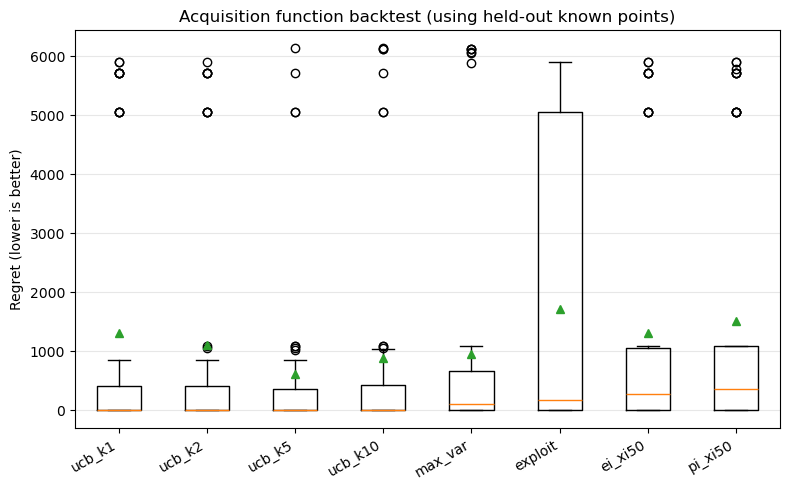

In [9]:
backtest_configs = [
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ucb_k10",  "acquisition": "ucb", "kappa": 10.0},
    {"name": "ei_xi50",  "acquisition": "ei",  "xi": 50.0},
    {"name": "pi_xi50",  "acquisition": "pi",  "xi": 50.0},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

backtest_results = backtest_acquisitions(
    X, y, bounds, backtest_configs,
    n_repeats=50, seed_frac=0.5, maximize=True,
    gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
)
print_backtest_summary(backtest_results)

fig = plot_acquisition_backtest(backtest_results)
plt.show()

## Compare kappa values -- the deciding cell

Two views. First `compare_kappa_proposals`, which optimises over all four axes and is shown mainly to demonstrate the problem: every `kappa` parks the three near-flat axes at box corners (x0 at its *lower* bound, x1 and x3 at their upper ones). Those coordinates are optimiser artifacts, not predictions.

Then the restricted view along the dominant axis, which is what the choice is actually made from.

**`kappa=1.0` is committed, and the reason is length-scale distance, not the mean's peak.** The GP mean along x2 does peak near 1.2745, but that peak is a **kernel artifact rather than a landmark**: it sits 0.1687 past the last observation, which is only **0.38 of one length-scale** (0.263 normalised = 0.439 in raw x2 units), exactly where the extrapolated gradient gives way to reversion toward the prior mean of about 437. Model-free there is no turnover at all -- `y` is still rising at the largest x2 sampled (0.879 gave 1089, then 1.106 gave 6147). So "step just past the peak" would be calibrating against an artifact.

The real criterion is to stay within roughly one length-scale of the data, where the model still carries information. `kappa` 0 to 2 all land in the 1.27-1.46 band, i.e. 0.4 to 1.0 length-scales out; `kappa=1` sits mid-band.

`kappa=5` is rejected structurally rather than by taste: it puts x2 exactly on the upper bound (1.6700), so `pad_fraction` -- an arbitrary choice -- would be picking the proposal instead of the model.

Two honest caveats on how weak the underlying trend is. Log `y` against x2 gives **r-squared = 0.23**, and the ascent is driven almost entirely by the last two points (at x2=0.21, `y` is 0.113; at x2=0.108 it is 233). A log-linear fit extrapolates to about 1585 at x2=1.3656 against the GP's 7344 -- not a rival prediction, since it under-predicts the incumbent tenfold, but a reminder that both extrapolations are weak. And the backtest's preference for `kappa=5`/`kappa=10` is really expressing "go far from the data", which in a restricted search just means "hit the box edge"; it does not override the structural objection.

=== unrestricted over all 4 axes (shown to demonstrate the problem) ===
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



-------------------------------------------------------------------------------------------
     0.5 | [0.   ,1.687,1.312,1.842] |  8465.8366 |  7706.5254 | 1518.6223 |          1.1517
       1 | [0.   ,1.687,1.358,1.842] |  9303.2872 |  7474.2383 | 1829.0489 |          1.1609
       2 | [0.   ,1.687,1.452,1.842] | 11410.5460 |  6694.2002 | 2358.1729 |          1.1847
       5 | [0.   ,1.687,1.669,1.842] | 19816.8999 |  4402.8629 | 3082.8074 |          1.2651
      10 | [0.   ,1.687,1.67 ,1.842] | 35244.9265 |  4388.8030 | 3085.6124 |          1.2657

how many coordinates sit on a bound in each unrestricted proposal?
  kappa=0.5   on_bound=3/4  in_hull=False
  kappa=1     on_bound=3/4  in_hull=False
  kappa=2     on_bound=3/4  in_hull=False
  kappa=5     on_bound=3/4  in_hull=False
  kappa=10    on_bound=4/4  in_hull=False


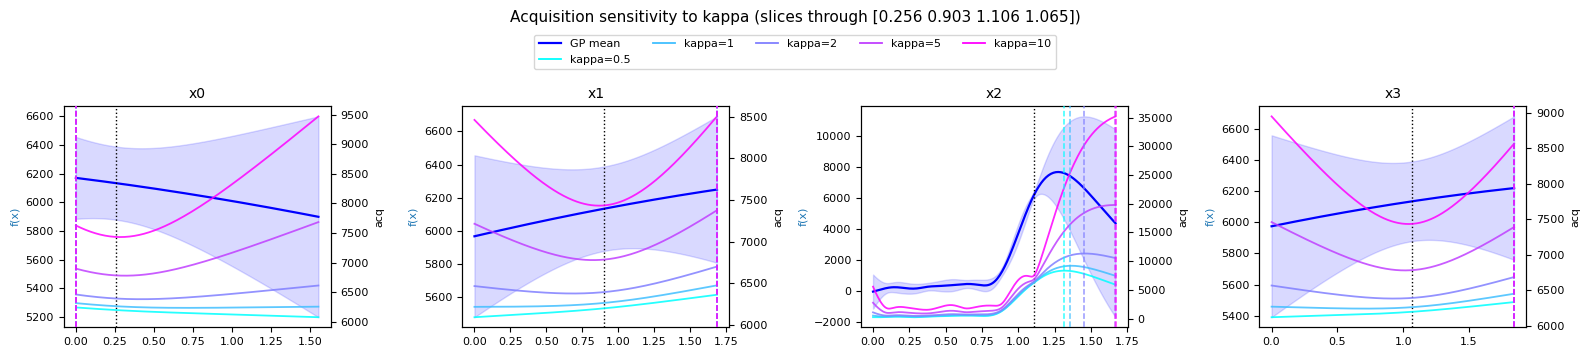


=== restricted to x2 (what the choice is made from) ===
x2 length-scale: 0.2629 normalised = 0.4390 raw; last observation at x2=1.1059

 kappa |        x2 |     step | length-scales out |  pred mean |  pred std | on bound
     0 |    1.2745 |  +0.1687 |              0.38 |    +7661.7 |    1217.2 | False
     1 |    1.3656 |  +0.2597 |              0.59 |    +7343.9 |    1856.4 | False
     2 |    1.4587 |  +0.3528 |              0.80 |    +6568.6 |    2382.5 | False
     5 |    1.6700 |  +0.5641 |              1.28 |    +4366.0 |    3083.3 | True

GP mean peaks along x2 at 1.2745 (mean +7661.7) -- but that is only 0.38 length-scales past the last
observation, i.e. where extrapolated gradient gives way to reversion toward
the prior mean (436.8). It is a kernel artifact, not a measured maximum:
the highest-x2 observations show y still rising -- x2=0.829 -> y=78.4, x2=0.879 -> y=1088.9, x2=1.106 -> y=6146.8

model-free check: log y ~ 3.836*x2 + 2.131, r^2 = 0.231 (weak)
  its extrapolati

In [10]:
print("=== unrestricted over all 4 axes (shown to demonstrate the problem) ===")
kappa_rows = compare_kappa_proposals(X, y, bounds, kappa_values=[0.5, 1.0, 2.0, 5.0, 10.0],
                                      maximize=True, n_restarts=30, random_state=0)
print_kappa_comparison(kappa_rows)
print("\nhow many coordinates sit on a bound in each unrestricted proposal?")
for row in kappa_rows:
    n_edge = sum(np.isclose(row["x_next"][d], bounds[d, 0])
                 or np.isclose(row["x_next"][d], bounds[d, 1]) for d in range(D))
    print(f"  kappa={row['kappa']:<5g} on_bound={n_edge}/{D}"
          f"  in_hull={bool(hull.find_simplex(row['x_next']) >= 0)}")

fig = plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()

print(f"\n=== restricted to x{DIM} (what the choice is made from) ===")
scan_grid = np.tile(incumbent, (4000, 1))
scan_grid[:, DIM] = np.linspace(bounds[DIM, 0], bounds[DIM, 1], 4000)
scan_norm = normalize(scan_grid, bounds)
scan_mean, scan_std = gp_check.predict(scan_norm, return_std=True)

# Express each candidate's step in LENGTH-SCALES past the last observation --
# that, not the GP's apparent peak, is the criterion (see the markdown above).
ls_raw = ls_after[DIM] * (bounds[DIM, 1] - bounds[DIM, 0])
last_obs = X[:, DIM].max()
print(f"x{DIM} length-scale: {ls_after[DIM]:.4f} normalised = {ls_raw:.4f} raw;"
      f" last observation at x{DIM}={last_obs:.4f}\n")
print(f"{'kappa':>6} | {'x' + str(DIM):>9} | {'step':>8} | {'length-scales out':>17}"
      f" | {'pred mean':>10} | {'pred std':>9} | on bound")
for k in [0.0, 1.0, 2.0, 5.0]:
    j = int(np.argmax(ucb_acquisition(scan_norm, gp_check, kappa=k, maximize=True)))
    xv = scan_grid[j, DIM]
    on_b = np.isclose(xv, bounds[DIM, 1]) or np.isclose(xv, bounds[DIM, 0])
    print(f"{k:6g} | {xv:9.4f} | {xv - incumbent[DIM]:+8.4f} | {(xv - last_obs) / ls_raw:17.2f}"
          f" | {scan_mean[j]:+10.1f} | {scan_std[j]:9.1f} | {on_b}")

peak = scan_grid[int(np.argmax(scan_mean)), DIM]
print(f"\nGP mean peaks along x{DIM} at {peak:.4f} (mean {scan_mean.max():+.1f}) --"
      f" but that is only {(peak - last_obs) / ls_raw:.2f} length-scales past the last")
print(f"observation, i.e. where extrapolated gradient gives way to reversion toward")
print(f"the prior mean ({y.mean():.1f}). It is a kernel artifact, not a measured maximum:")
hi = np.argsort(X[:, DIM])[-3:]
print("the highest-x%d observations show y still rising -- %s" % (
    DIM, ", ".join(f"x{DIM}={X[i, DIM]:.3f} -> y={y[i]:.1f}" for i in hi)))

# How weak is the underlying trend, model-free?
if (y > 0).all():
    coef = np.polyfit(X[:, DIM], np.log(y), 1)
    r2 = pearsonr(X[:, DIM], np.log(y))[0] ** 2
    print(f"\nmodel-free check: log y ~ {coef[0]:.3f}*x{DIM} + {coef[1]:.3f},"
          f" r^2 = {r2:.3f} (weak)")
    print(f"  its extrapolation at the kappa=1 point: y ~"
          f" {np.exp(np.polyval(coef, 1.3656)):.0f}, vs the GP's ~7344.")
    print("  It under-predicts the incumbent tenfold, so it is not a rival prediction --")
    print("  just a reminder that every extrapolation here is on thin evidence.")

KAPPA = 1.0
print(f"\nusing kappa = {KAPPA} (dimensionless -- no y-scaling needed),"
      f" searching x{DIM} only")

## Propose the next point

x2 from the restricted UCB scan; x0/x1/x3 held at the incumbent because they barely move the response and would otherwise be parked at arbitrary box corners.

The convex-hull check runs as on functions 3 and 4, but here a `False` is **expected and intended** -- the whole argument is that the ridge continues past the sampled region. What the cell does veto is a proposal landing exactly on a bound, since that would mean `pad_fraction` is choosing the point rather than the model.

In [11]:
j = int(np.argmax(ucb_acquisition(scan_norm, gp_check, kappa=KAPPA, maximize=True)))
x_next = scan_grid[j].copy()
gp = gp_check

mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu[0]:.6g}, predicted std: {sigma[0]:.6g}")
print(f"current best observed y: {y.max():.6g}"
      f"  -> predicted improvement: {mu[0] - y.max():+.6g}")
print(f"step along x{DIM} from the incumbent: {x_next[DIM] - incumbent[DIM]:+.4f}")
print(f"other coordinates unchanged from the incumbent:"
      f" {np.allclose(np.delete(x_next, DIM), np.delete(incumbent, DIM))}")

# --- Checks --------------------------------------------------------------
on_edge = [d for d in range(D)
           if np.isclose(x_next[d], bounds[d, 0]) or np.isclose(x_next[d], bounds[d, 1])]
print("\ndimensions where x_next sits on a bound:", on_edge or "none")
if on_edge:
    print("*** A coordinate is on a bound, so pad_fraction is choosing the proposal")
    print("    rather than the model. Lower kappa until it comes off the edge. ***")

outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("dimensions outside the observed data range:", outside or "none")
print(f"inside the convex hull of the observations: "
      f"{bool(hull.find_simplex(x_next) >= 0)}  (False is expected here -- see above)")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.4f}")
print("nearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+10.2f}  X={np.round(X[i], 3)}")

--- Next point to evaluate (bounds shape (4, 2)) ---
x_next: [0.25621  0.903056 1.365584 1.065351]
2.65**2 * Matern(length_scale=[10, 10, 0.263, 9.07], nu=2.5) + WhiteKernel(noise_level=0.00503)
GP predicted mean: 7343.93, predicted std: 1856.4
current best observed y: 6146.78  -> predicted improvement: +1197.15
step along x2 from the incumbent: +0.2597
other coordinates unchanged from the incumbent: True

dimensions where x_next sits on a bound: none
dimensions outside the observed data range: [2]
inside the convex hull of the observations: False  (False is expected here -- see above)

distance from the incumbent: 0.2597
nearest 3 observations to x_next:
  dist=0.2597  y=  +6146.78  X=[0.256 0.903 1.106 1.065]
  dist=0.5248  y=  +1088.86  X=[0.224 0.846 0.879 0.879]
  dist=0.7670  y=   +431.61  X=[0.12  0.863 0.643 0.85 ]


## Visualise the GP and acquisition function via 1D slices

Each panel holds the other three dimensions fixed at the current best observed point and sweeps one dimension. Dotted line is the fixed centre, dashed red is the proposed `x_next`, green is UCB.

What to expect, and it makes the whole argument visible in one figure: the **x2 panel** shows a steep ridge that is still rising at the right-hand edge of the observations, with `x_next` placed just past the mean's peak. The **x0, x1 and x3 panels are nearly flat** by comparison -- the y-axis range on each is a few hundred against x2's several thousand. That flatness is why those three coordinates are pinned at the incumbent rather than optimised.

This is a *partial* view: it shows the GP along each axis near the best point, not interactions between dimensions.

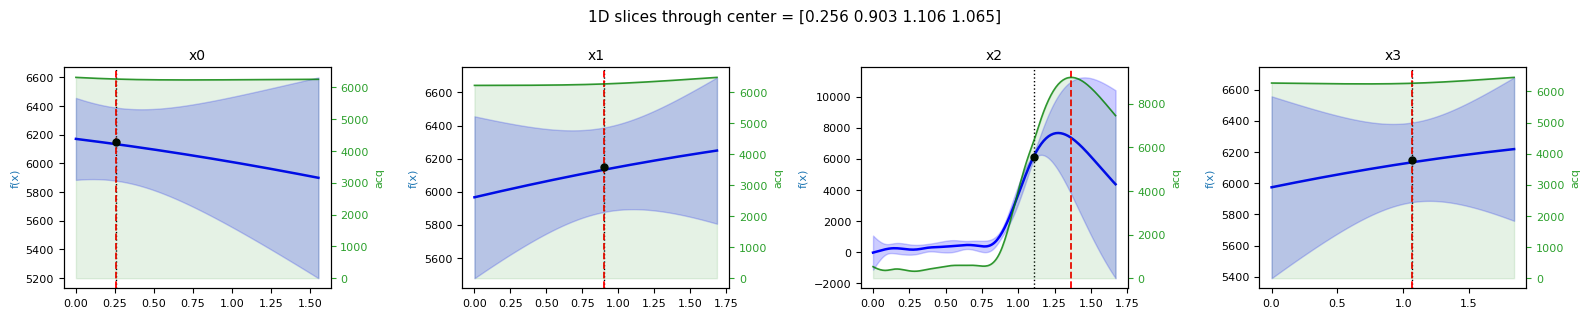

In [12]:
fig = plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per observation, leaving it out, and predicts it from the rest. At D=4 this is the main way to judge the surrogate, since the fitted surface can't be inspected directly.

Expect the new best point to be the worst-predicted by a wide margin -- that is the 17-sigma miss quantified earlier, reappearing here. The rest of the points should mostly fall inside their intervals. The reading to take away is not "the model is broken" but "the model is badly calibrated specifically in the direction we are moving", which is an argument for treating its predicted `std` as a floor rather than an estimate.

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/pytho

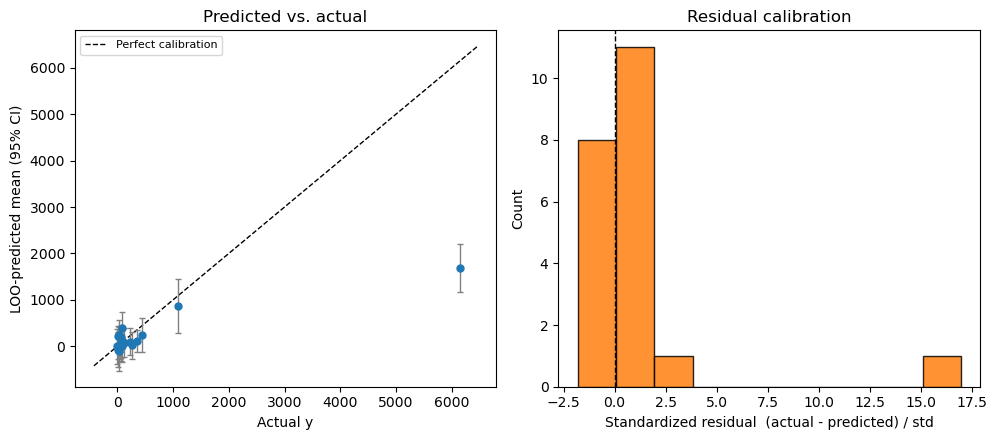

points inside their own 95% LOO interval: 19/21
worst-predicted point: index 20 -> true 6147, predicted 1686 (std 263.1)
is that the collected best point? True


In [13]:
pred_mean, pred_std = loo_predictions(X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20})
fig = plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")

worst = int(np.argmax(np.abs(y - pred_mean)))
print(f"worst-predicted point: index {worst} -> true {y[worst]:.4g},"
      f" predicted {pred_mean[worst]:.4g} (std {pred_std[worst]:.4g})")
print("is that the collected best point?", worst == n_initial)

## Iteration diagnostics

`compute_iteration_diagnostics` replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters, and domain-wide uncertainty were at each past proposal -- no persisted log involved.

It applies one acquisition setting to the whole history, taken from `KAPPA` so it can't drift from what the proposal used. The single recorded observation was proposed under the old sweep's `pi`/`xi=0.01`, not `ucb`/`kappa=1`, so its replayed acquisition value describes a decision never made that way -- treat that column as meaningless until the history is UCB throughout. The GP-hyperparameter and `domain_mean_std` columns are unaffected by the mismatch.

It also assumes row order is true chronological order. `plot_bo_diagnostics` is skipped (it hard-codes a 2D scatter panel and this is 4D); the trend plots below are dimension-agnostic and gated on having a few completed iterations.

In [14]:
history = None
if len(new_y) == 0:
    print("No observations beyond the initial batch yet -- nothing to replay.")
    print("Best y so far:", y.max())
else:
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                             acquisition="ucb", kappa=KAPPA, maximize=True)
    print("Best y so far:", np.nanmax(history["y"]))
    print("completed iterations beyond the initial batch:", len(new_y))

    if len(new_y) >= 3:
        for plot_fn in (plot_convergence, plot_acquisition_decay,
                        plot_uncertainty_shrinkage, plot_step_distance):
            plot_fn(history)
            plt.show()
    else:
        print(f"\nOnly {len(new_y)} completed iteration(s) -- need at least 3 for the trend\n"
              "plots to say anything. Skipping them; the raw fields are below.")

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Best y so far: 6146.77907747422
completed iterations beyond the initial batch: 1

Only 1 completed iteration(s) -- need at least 3 for the trend
plots to say anything. Skipping them; the raw fields are below.


## Raw diagnostic fields

In [15]:
if history is not None:
    print("y:", np.round(history["y"], 3))
    print("\niteration:", history["iteration"])
    print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
    print("\npred_mean at proposal time:", history["pred_mean"])
    print("\nlength_scale:", history["length_scale"])
    print("\ndomain_mean_std:", history["domain_mean_std"])

y: [6.444300e+01 1.830100e+01 1.130000e-01 4.211000e+00 2.583710e+02
 7.843400e+01 5.757200e+01 1.095720e+02 8.848000e+00 2.332240e+02
 2.442300e+01 6.442000e+01 6.347700e+01 7.972900e+01 3.558070e+02
 1.088860e+03 2.886700e+01 4.518200e+01 4.316130e+02 9.972000e+00
 6.146779e+03]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

acq_value (NaN = initial batch; see the caveat above): [          nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
 1948.84653991]

pred_mean at proposal time: [          nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan           nan           nan
           nan           nan           nan 

In [16]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.256210-0.903056-1.365584-1.065351

full precision (use for next week's new_X):
0.25621-0.903056-1.3655839859899606-1.065351
